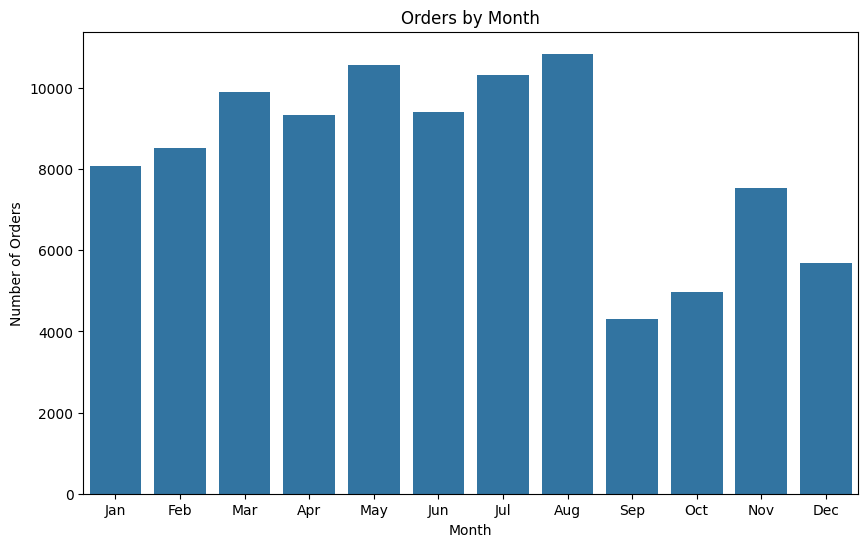

Highest Orders Month: 8


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
orders = pd.read_csv("olist_orders_dataset.csv")

# Convert order purchase timestamp to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Extract month
orders['month'] = orders['order_purchase_timestamp'].dt.month

# Count orders per month
monthly_orders = orders['month'].value_counts().sort_index()

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=monthly_orders.index, y=monthly_orders.values)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(range(0,12),
           ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.show()

# Highest month
print("Highest Orders Month:", monthly_orders.idxmax())

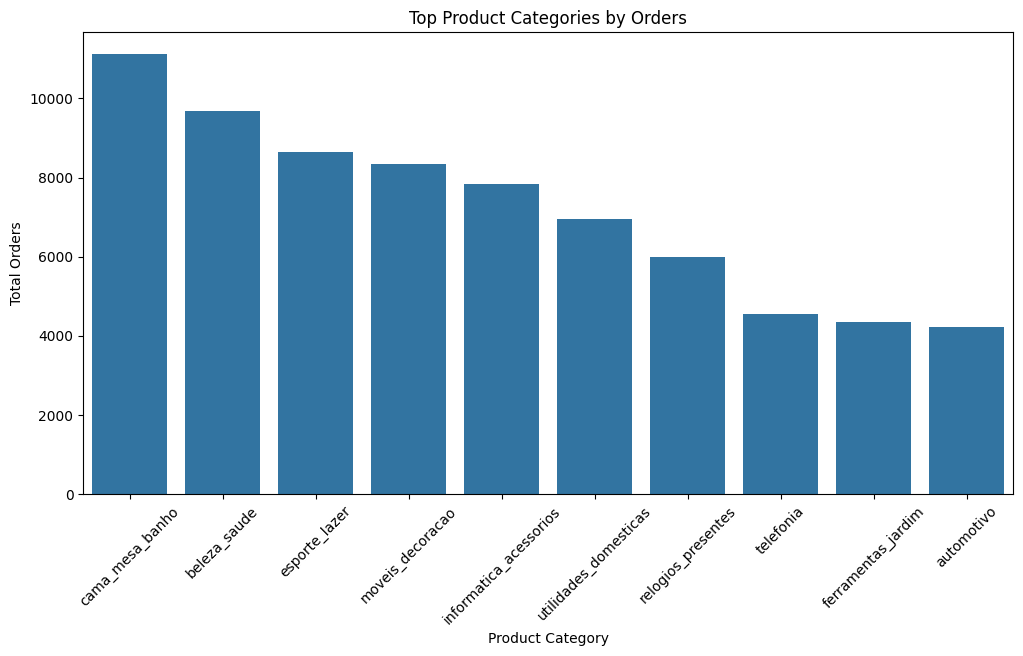

In [19]:
#Which product categories generate the most orders?
# Load datasets
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

# Merge datasets
merged = pd.merge(order_items, products, on="product_id")

# Count orders by category
category_orders = merged['product_category_name'].value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=category_orders.index, y=category_orders.values)

plt.title("Top Product Categories by Orders")
plt.xlabel("Product Category")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)

plt.show()

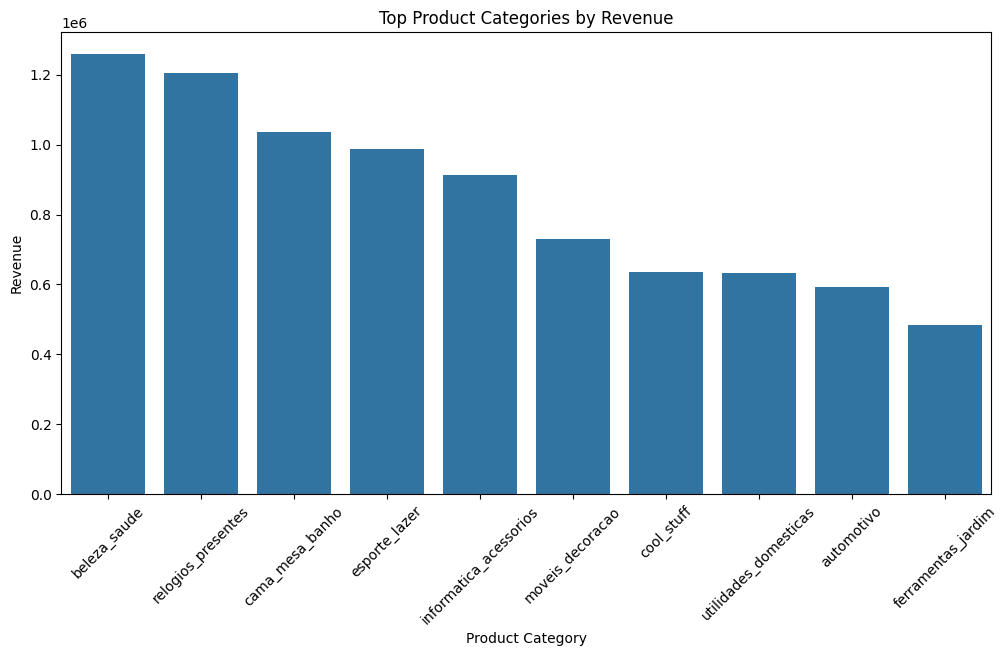

In [21]:
#Which product categories generate the highest revenue?
# Group by category and sum revenue
category_revenue = merged.groupby(
    'product_category_name'
)['price'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=category_revenue.index, y=category_revenue.values)

plt.title("Top Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()